In [1]:
using LinearAlgebra
using Plots

gr()

Plots.GRBackend()

In [2]:
function compose_candidate(x, grad_x, deltas, λ)
    y = x - λ[1] * grad_x
    for j in 2:length(λ)
        y += λ[j] * deltas[j - 1]
    end
    return y
end

compose_candidate (generic function with 1 method)

In [3]:
function multicriteria_search_v2(f, grad_f, x0;
                              tol=1e-6,
                              max_iter=400,
                              reset_each_n_plus_one=true,
                              verbose=true,
                              lambda_count=2)
    n = length(x0)

    x = copy(x0)
    
    # Храним несколько предыдущих шагов
    deltas_history = Vector{Vector{Float64}}()

    history = [(
        iter=0,
        x=copy(x),
        fx=f(x),
        grad_norm=norm(grad_f(x)),
        λ0=0.0,
        λ1=0.0,
        Δx_norm=0.0
    )]

    converged = false

    for k in 1:max_iter
        grad_x = grad_f(x)
        grad_norm = norm(grad_x)

        if grad_norm < tol
            converged = true
            if verbose
                println("Сходимость достигнута на итерации $(k - 1): ||∇f|| = $(grad_norm)")
            end
            break
        end

        # Получаем предыдущие шаги
        if k > 1
            Δx_prev = x - history[end].x
            push!(deltas_history, copy(Δx_prev))
            
            # Ограничиваем размер истории до lambda_count - 1
            while length(deltas_history) > lambda_count - 1
                popfirst!(deltas_history)
            end
            
            # Сброс при необходимости
            if reset_each_n_plus_one && ((k - 1) % (n + 1) == 0)
                empty!(deltas_history)
            end
        else
            deltas_history = Vector{Vector{Float64}}()
        end

        if lambda_count == 2
            # Для lambda_count == 2 передаем коллекцию с одним элементом
            if isempty(deltas_history)
                deltas_for_solve = [zeros(n)]
            else
                deltas_for_solve = [deltas_history[end]]
            end
            λ_init = [1.0, 1.0]
        else
            # Для lambda_count > 2 используем всю историю
            deltas_for_solve = isempty(deltas_history) ? Vector{Vector{Float64}}() : deltas_history
            λ_init = nothing
        end

        λ = solve_lambdas_NelderMid(f, grad_f, x, grad_x, deltas_for_solve; λ_init=λ_init)
        x_next = compose_candidate(x, grad_x, deltas_for_solve, λ)
        λ0 = λ[1]
        λ1 = length(λ) > 1 ? λ[2] : 0.0

        x = x_next

        push!(history, (
            iter=k,
            x=copy(x),
            fx=f(x),
            grad_norm=norm(grad_f(x)),
            λ0=λ0,
            λ1=λ1,
            Δx_norm=isempty(deltas_history) ? 0.0 : norm(deltas_history[end])
        ))
    end

    if !converged && verbose
        println("Достигнут лимит итераций $(max_iter), финальная ||∇f|| = $(history[end].grad_norm)")
    end

    return x, history
end

multicriteria_search_v2 (generic function with 1 method)

In [4]:
function f_schwefel(x)
    n = length(x)
    result = 0.0
    for xi in x
        if !isfinite(xi)
            return Inf  # Если вход Inf/NaN, возвращаем Inf
        end
        abs_xi = abs(xi)
        if abs_xi > 1e10  # Ограничиваем очень большие значения
            result += abs_xi * 1.0  # Приближение для очень больших xi
        else
            s = sqrt(abs_xi)
            if isfinite(s)
                result += xi * sin(s)
            else
                result += abs_xi * 1.0
            end
        end
    end
    return 418.9829 * n - result
end

function grad_schwefel(x)
    g = zeros(length(x))
    for i in eachindex(x)
        xi = x[i]
        if !isfinite(xi)
            g[i] = 0.0
            continue
        end
        
        abs_xi = abs(xi)
        if abs_xi > 1e10
            g[i] = -1.0  # Приближение для очень больших xi
        else
            s = sqrt(abs_xi)
            if s < 1e-12
                g[i] = 0.0
            elseif isfinite(s)
                g[i] = -(sin(s) + 0.5 * s * cos(s))
            else
                g[i] = -1.0
            end
        end
    end
    return g
end

grad_schwefel (generic function with 1 method)

In [5]:
function plot_run_2d(f, hist; xlim=(-5.0, 5.0), ylim=(-5.0, 5.0), title_prefix="", auto_zoom=true, zoom_pad=0.2, min_span=0.5)
    xs = [h.x[1] for h in hist]
    ys = [h.x[2] for h in hist]

    if auto_zoom && length(xs) > 0
        xmin, xmax = minimum(xs), maximum(xs)
        ymin, ymax = minimum(ys), maximum(ys)
        xspan = max(xmax - xmin, min_span)
        yspan = max(ymax - ymin, min_span)
        xpad = zoom_pad * xspan
        ypad = zoom_pad * yspan
        xlim = (xmin - xpad, xmax + xpad)
        ylim = (ymin - ypad, ymax + ypad)
    end

    xg = range(xlim[1], xlim[2], length=260)
    yg = range(ylim[1], ylim[2], length=260)
    Z = [f([x, y]) for y in yg, x in xg]

    p = contour(
        xg,
        yg,
        Z,
        levels=40,
        linewidth=1,
        c=:plasma,
        xlabel="x₁",
        ylabel="x₂",
        title=title_prefix * ": trajectory",
        legend=false
    )

    plot!(p, xs, ys, lw=1.6, linealpha=0.85, color=:red, label="trajectory")

    scatter!(
        p,
        xs,
        ys,
        marker=:circle,
        ms=4,
        color=:red,
        markerstrokewidth=0.8,
        markerstrokecolor=:black,
        alpha=1.0,
        label="all points"
    )

    scatter!(p, [xs[1]], [ys[1]], marker=:diamond, ms=8, color=:orange, markerstrokecolor=:black, markerstrokewidth=1.0, label="start")

    return p
end

plot_run_2d (generic function with 1 method)


===== Schwefel: сравнение по числу lambda-параметров =====
lambda_count=2 | steps=59 | f_final=-78.95169403157297 | ||∇f||=7.725110192092378e-14
lambda_count=3 | steps=64 | f_final=-78.95169403157297 | ||∇f||=6.154612236036189e-14
lambda_count=5 | steps=64 | f_final=-78.95169403157297 | ||∇f||=6.154612236036189e-14
lambda_count=10 | steps=64 | f_final=-78.95169403157297 | ||∇f||=6.154612236036189e-14
lambda_count=100 | steps=64 | f_final=-78.95169403157297 | ||∇f||=6.154612236036189e-14


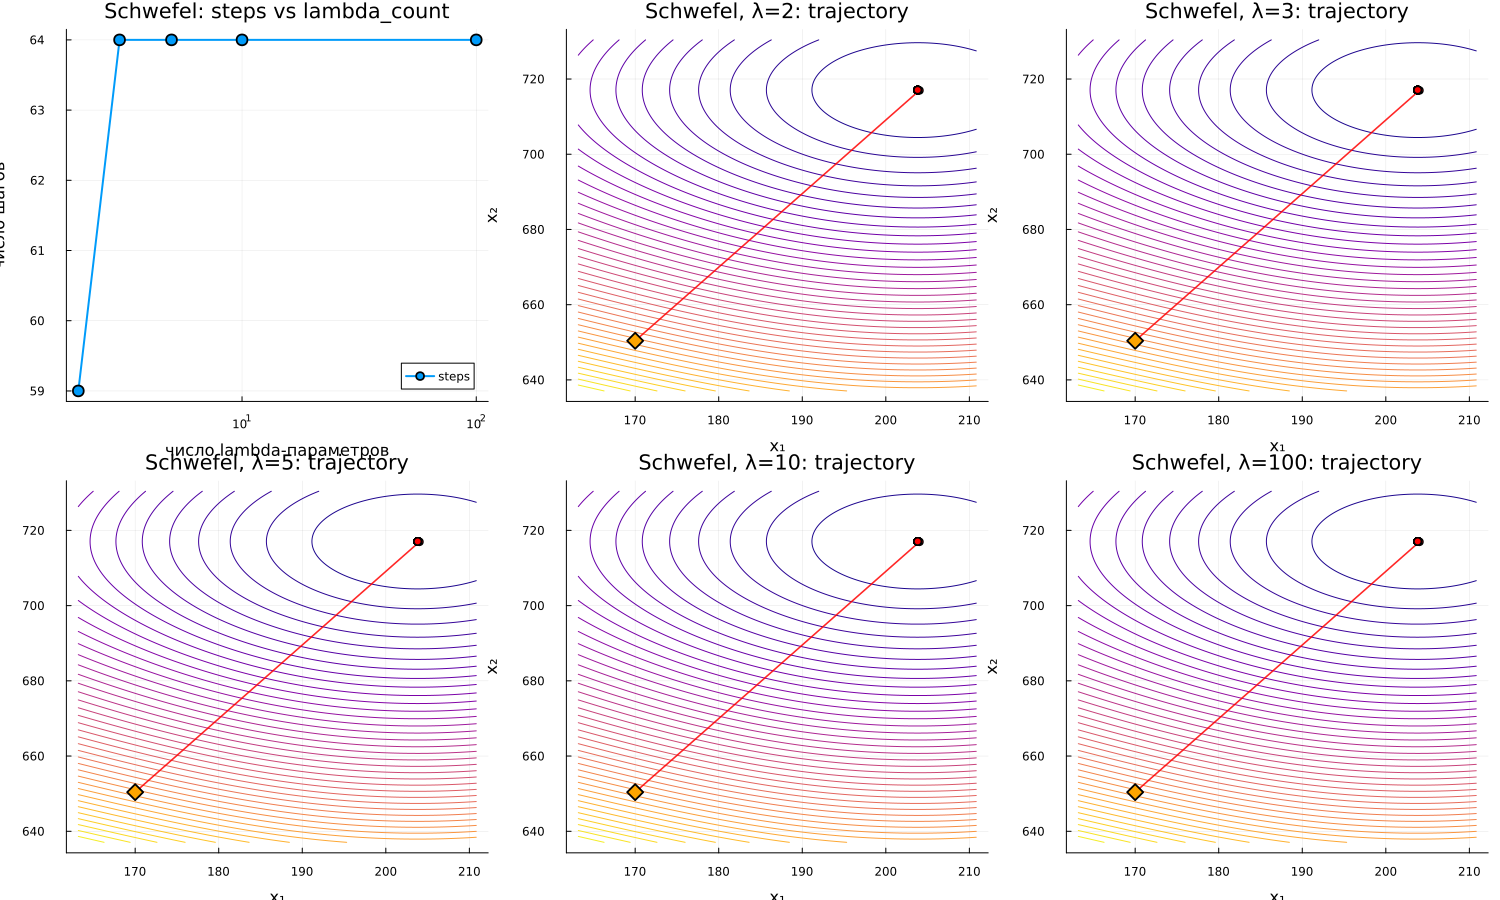

In [6]:
function solve_lambdas_NelderMid(f, grad_f, x, grad_x, deltas;
                              λ_init=nothing,
                              tol=1e-8,
                              max_iter=200,
                              armijo_c=1e-4,
                              backtrack_beta=0.5)
    m = 1 + length(deltas)
    λ0 = isnothing(λ_init) ? ones(m) : copy(λ_init)

    g(λvec) = f(compose_candidate(x, grad_x, deltas, λvec))

    function clampλ!(v)
        @inbounds for i in eachindex(v)
            v[i] = clamp(v[i], -100.0, 100.0)
            if !isfinite(v[i])
                v[i] = 0.0
            end
        end
        return v
    end

    clampλ!(λ0)

    α = 1.0
    γ = 2.0
    ρ = 0.5
    σ = 0.5

    step = m <= 10 ? 0.2 : (m <= 50 ? 0.1 : 0.05)

    simplex = Vector{Vector{Float64}}(undef, m + 1)
    vals    = Vector{Float64}(undef, m + 1)

    simplex[1] = copy(λ0)
    vals[1] = (isfinite(g(simplex[1])) ? g(simplex[1]) : Inf)

    for i in 1:m
        v = copy(λ0)
        v[i] += step
        clampλ!(v)
        simplex[i + 1] = v
        gi = g(v)
        vals[i + 1] = isfinite(gi) ? gi : Inf
    end

    function sort_simplex!(simplex, vals)
        p = sortperm(vals)
        simplex[:] = simplex[p]
        vals[:] = vals[p]
        return nothing
    end

    function simplex_spread(vals)
        vmin = vals[1]
        vmax = vals[end]
        if !isfinite(vmin) || !isfinite(vmax)
            return Inf
        end
        return abs(vmax - vmin)
    end

    for it in 1:max_iter
        sort_simplex!(simplex, vals)

        if simplex_spread(vals) < tol
            break
        end

        best = simplex[1]
        worst = simplex[end]
        second_worst = simplex[end - 1]

        c = zeros(m)
        for i in 1:m
            c .+= simplex[i]
        end
        c ./= m

        xr = c .+ α .* (c .- worst)
        clampλ!(xr)
        fr = g(xr); fr = isfinite(fr) ? fr : Inf

        if fr < vals[1]
            xe = c .+ γ .* (xr .- c)
            clampλ!(xe)
            fe = g(xe); fe = isfinite(fe) ? fe : Inf
            if fe < fr
                simplex[end] = xe
                vals[end] = fe
            else
                simplex[end] = xr
                vals[end] = fr
            end
        elseif fr < vals[end - 1]
            simplex[end] = xr
            vals[end] = fr
        else
            if fr < vals[end]
                xc = c .+ ρ .* (xr .- c)
            else
                xc = c .- ρ .* (c .- worst)
            end
            clampλ!(xc)
            fc = g(xc); fc = isfinite(fc) ? fc : Inf

            if fc < vals[end]
                simplex[end] = xc
                vals[end] = fc
            else
                # shrink
                for i in 2:(m + 1)
                    simplex[i] = best .+ σ .* (simplex[i] .- best)
                    clampλ!(simplex[i])
                    fi = g(simplex[i])
                    vals[i] = isfinite(fi) ? fi : Inf
                end
            end
        end
    end

    sort_simplex!(simplex, vals)
    return simplex[1]
end

lambda_counts = [2, 3, 5, 10, 100]

x0_sch_cmp = [170.0, 650.4]
tol_sch_cmp = 1e-13
max_iter_sch_cmp = 1200

lambda_results = NamedTuple[]
traj_plots = Any[]

for lc in lambda_counts
    x_star_lc, hist_lc = multicriteria_search_v2(
        f_schwefel,
        grad_schwefel,
        x0_sch_cmp;
        lambda_count=lc,
        tol=tol_sch_cmp,
        max_iter=max_iter_sch_cmp,
        verbose=false
    )

    steps_lc = length(hist_lc) - 1
    push!(lambda_results, (
        lambda_count=lc,
        steps=steps_lc,
        x_star=x_star_lc,
        f_final=f_schwefel(x_star_lc),
        grad_norm_final=norm(grad_schwefel(x_star_lc)),
        history=hist_lc
    ))

    p_traj = plot_run_2d(
        f_schwefel,
        hist_lc;
        title_prefix="Schwefel, λ=$(lc)",
        auto_zoom=true,
        min_span=10.0
    )
    push!(traj_plots, p_traj)
end

println("\n===== Schwefel: сравнение по числу lambda-параметров =====")
for r in lambda_results
    println("lambda_count=$(r.lambda_count) | steps=$(r.steps) | f_final=$(r.f_final) | ||∇f||=$(r.grad_norm_final)")
end

p_steps_lambda = plot(
    [r.lambda_count for r in lambda_results],
    [r.steps for r in lambda_results],
    marker=:circle,
    ms=6,
    lw=2,
    xlabel="число lambda-параметров",
    ylabel="число шагов",
    title="Schwefel: steps vs lambda_count",
    label="steps",
    xscale=:log10
)

plot(
    p_steps_lambda,
    traj_plots...,
    layout=(2, 3),
    size=(1500, 900)
)